# Guessing the most unique country name by English Language

So this is inspired by [
Eliminating Country Names Until I Find The Most Unique](https://www.youtube.com/watch?v=tnwMre_cVkc) YouTube Video by [
Name Explain](https://www.youtube.com/@NameExplain) uploaded on 12 Dec 2025. Towards the end of the video in final elimination round the Youtuber uses mean by frequency of letters in English Language as described in [Letter Frequencies in English](https://mathcenter.oxford.emory.edu/site/math125/englishLetterFreqs/) published as part of Math125 Course offered by Oxford College's Department of Mathematics and Computer Science.<sup>[\[Archived Link\]](https://web.archive.org/web/20260409183439/https://mathcenter.oxford.emory.edu/site/math125/englishLetterFreqs/)</sup>. The list of countries is same as [UN Official Name of Countries](https://www.un.int/protocol/sites/www.un.int/files/Protocol%20and%20Liaison%20Service/officialnamesofcountries.pdf).<sup>[\[Archived Link\]](https://web.archive.org/web/20260429225736/https://www.un.int/protocol/sites/www.un.int/files/Protocol%20and%20Liaison%20Service/officialnamesofcountries.pdf)</sup>.

Now there is already a measure of how rare a sequence of letters (or words or any sequence) is, it is called [perplexity](https://d2l.ai/chapter_recurrent-neural-networks/language-model.html#perplexity). Roughly it is measure of how likely is one to get a random piece of letters, the amount of surprise it produces *i.e. how unique it is*. Higher it is, the more unique it is.  

$\frac{1}{n} \sum_{t=1}^n -\log P(x_t \mid x_{t-1}, \ldots, x_1)$

Now we can only predict the frequency of one letter from the given distribution, so assume zero order markov model and it becomes

$\frac{1}{n} \sum_{t=1}^n -\log P(x_t)$

## Steps

### 1. Download the list of countries
### 2. Extract the table of frequency
### 3. Calculate perplexity of each country
### 4. Visualize the histogram

### 1. Download the list of countries

In [1]:
un_country_list_url = 'https://www.un.int/protocol/sites/www.un.int/files/Protocol%20and%20Liaison%20Service/officialnamesofcountries.pdf'

In [2]:
%%capture
!pip install pypdf
!pip install playwright
!playwright install
!apt-get update && apt-get install -y libatk1.0-0 libatk-bridge2.0-0 libgtk-3-0 libgbm-dev

In [3]:
import pypdf
from playwright.async_api import async_playwright
from io import BytesIO
import re

In [4]:
async with async_playwright() as p:
      browser = await p.chromium.launch()
      page = await browser.new_page()
      resp = await page.request.get(un_country_list_url)
      raw_pdf_bytes = await resp.body()
      await browser.close()

In [5]:
pdf_io = BytesIO(raw_pdf_bytes)
pdf_io.seek(0)
pdf_reader = pypdf.PdfReader(pdf_io)

In [6]:
total_pdf_content = ''

In [7]:
for page in pdf_reader.pages:
    total_pdf_content += page.extract_text()


In [18]:
total_pdf_content[:100]

'OFFICIAL NAMES OF THE UNITED NATIONS MEMBERSHIP \n \nIslamic Republic of Afghanistan  \nRepublic of Alb'

In [19]:
list_of_countries = total_pdf_content.split('\n')

In [20]:
list_of_countries = [re.sub(r'\d', '', country) for country in list_of_countries]

In [21]:
list_of_countries = [list_of_countries[i].strip() for i in range(1, len(list_of_countries)) if list_of_countries[i].strip() != '']

In [22]:
list_of_countries = [' '.join([x.strip() for x in country.split() if x.strip() != '']) for country in list_of_countries]

In [23]:
list_of_countries[:10]

['Islamic Republic of Afghanistan',
 'Republic of Albania',
 'People’s Democratic Republic of Algeria',
 'Principality of Andorra',
 'Republic of Angola',
 'Antigua and Barbuda',
 'Republic of Argentina',
 'Republic of Armenia',
 'Commonwealth of Australia',
 'Republic of Austria']

## 2. Extract Table of Frequency

In [24]:
%%capture
!pip install bs4

In [25]:
from bs4 import BeautifulSoup
from playwright.async_api import async_playwright
import requests

In [26]:
freq_url = 'https://mathcenter.oxford.emory.edu/site/math125/englishLetterFreqs/'

In [29]:
async with async_playwright() as p:
      browser = await p.chromium.launch()
      page = await browser.new_page()
      resp = await page.request.get(freq_url)
      raw_html = await resp.text()
      await browser.close()

In [31]:
raw_html[:100]

'<html>\r\n<head>\r\n<title>Letter Frequencies in English</title><link rel="stylesheet" type="text/css" h'

In [32]:
bs_parser = BeautifulSoup(raw_html, 'html.parser')

In [40]:
table_obj = bs_parser.find('body').find_all('table')[1]

In [41]:
table_obj

<table><tr><td align="center" colspan="2"><b>By letter</b></td><td align="center" colspan="2"><b>By frequency</b></td></tr><tr><td><b>Letter</b></td><td>Frequency</td><td><b>Letter</b></td><td>Frequency</td></tr><tr><td><b>a</b></td><td>0.08167</td><td><b>e</b></td><td>0.12702</td></tr><tr><td><b>b</b></td><td>0.01492</td><td><b>t</b></td><td>0.09056</td></tr><tr><td><b>c</b></td><td>0.02782</td><td><b>a</b></td><td>0.08167</td></tr><tr><td><b>d</b></td><td>0.04253</td><td><b>o</b></td><td>0.07507</td></tr><tr><td><b>e</b></td><td>0.12702</td><td><b>i</b></td><td>0.06966</td></tr><tr><td><b>f</b></td><td>0.02228</td><td><b>n</b></td><td>0.06749</td></tr><tr><td><b>g</b></td><td>0.02015</td><td><b>s</b></td><td>0.06327</td></tr><tr><td><b>h</b></td><td>0.06094</td><td><b>h</b></td><td>0.06094</td></tr><tr><td><b>i</b></td><td>0.06966</td><td><b>r</b></td><td>0.05987</td></tr><tr><td><b>j</b></td><td>0.00153</td><td><b>d</b></td><td>0.04253</td></tr><tr><td><b>k</b></td><td>0.00772</td><

In [46]:
def convert_table_html_to_dict(table_ob):
  rows = table_ob.find_all('tr')
  table_dict = {}
  for row in rows[2:]:
    row_data = row.find_all('td')
    if len(row_data) == 4:
      table_dict[row_data[0].text] = float(row_data[1].text)
  return table_dict

In [47]:
freq_dict = convert_table_html_to_dict(table_obj)

In [48]:
freq_dict

{'a': 0.08167,
 'b': 0.01492,
 'c': 0.02782,
 'd': 0.04253,
 'e': 0.12702,
 'f': 0.02228,
 'g': 0.02015,
 'h': 0.06094,
 'i': 0.06966,
 'j': 0.00153,
 'k': 0.00772,
 'l': 0.04025,
 'm': 0.02406,
 'n': 0.06749,
 'o': 0.07507,
 'p': 0.01929,
 'q': 0.00095,
 'r': 0.05987,
 's': 0.06327,
 't': 0.09056,
 'u': 0.02758,
 'v': 0.00978,
 'w': 0.0236,
 'x': 0.0015,
 'y': 0.01974,
 'z': 0.00074}

### 3. Calculate the Perplexity of Each Country

Mean of all words' perplexity in a country

In [49]:
from math import log

In [56]:
def perplexity(country):
  list_of_words = country.split()
  total_perpelixty = 0.0
  for word in list_of_words:
    perplexity = 0.0
    for ch in word.lower():
      if ch not in freq_dict:
        continue
      perplexity += -log(freq_dict[ch])
    perplexity /= len(word)
    total_perpelixty += perplexity
  return total_perpelixty/len(list_of_words)

In [57]:
country_score_dict = {}

In [58]:
for country in list_of_countries:
  country_score_dict[country] = perplexity(country)

### 4. Visualize the score of country

In [60]:
import pandas

In [61]:
df = pandas.DataFrame(list(country_score_dict.items()), columns=['Country', 'Score'])

In [62]:
df.head()

,Country,Score
0,Islamic Republic of Afghanistan,3.078340
1,Republic of Albania,3.118626
2,People’s Democratic Republic of Algeria,2.949792
3,Principality of Andorra,3.002844
4,Republic of Angola,3.119660


<Axes: >

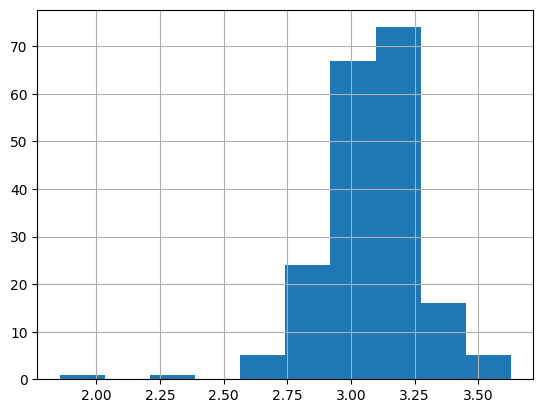

In [63]:
df['Score'].hist()

In [65]:
df[df['Score'] == df['Score'].max()]['Country']

,Country
84,Japan
